In [36]:
from nb201 import sample_nb201_networks
from supernet import Supernet

networks = sample_nb201_networks(N=1)

supernet = Supernet()
supernet.build(networks)
print(supernet)
# Supernet(10 subnet, 6 archi, N op totali)

supernet.summary()
# SuperEdge('0'→'1', MixedOp(['conv3x3', 'skip', 'conv1x1']), dag_map={0:0, 1:2, ...})
# ...

# dopo il training:
# accuracies = supernet.eval_subnets(networks, train_loader, eval_loader)

Supernet(1 subnet note, 6 archi, 6 op totali)
Supernet(1 subnet note, 6 archi, 6 op totali)
  SuperEdge('0'→'1', MixedOp(['conv1x1']))
  SuperEdge('0'→'2', MixedOp(['conv1x1']))
  SuperEdge('0'→'3', MixedOp(['skip']))
  SuperEdge('1'→'2', MixedOp(['conv3x3']))
  SuperEdge('1'→'3', MixedOp(['skip']))
  SuperEdge('2'→'3', MixedOp(['skip']))


In [37]:
networks = sample_nb201_networks(N=1)
supernet.expand(networks)

supernet.summary()

Supernet(2 subnet note, 6 archi, 12 op totali)
  SuperEdge('0'→'1', MixedOp(['conv1x1', 'skip']))
  SuperEdge('0'→'2', MixedOp(['conv1x1', 'skip']))
  SuperEdge('0'→'3', MixedOp(['skip', 'avg_pool3x3']))
  SuperEdge('1'→'2', MixedOp(['conv3x3', 'skip']))
  SuperEdge('1'→'3', MixedOp(['skip', 'conv3x3']))
  SuperEdge('2'→'3', MixedOp(['skip', 'conv3x3']))


Supernet(2 subnet note, 6 archi, 12 op totali)
  SuperEdge('0'→'1', MixedOp(['conv1x1', 'skip']))
  SuperEdge('0'→'2', MixedOp(['conv1x1', 'skip']))
  SuperEdge('0'→'3', MixedOp(['skip', 'avg_pool3x3']))
  SuperEdge('1'→'2', MixedOp(['conv3x3', 'skip']))
  SuperEdge('1'→'3', MixedOp(['skip', 'conv3x3']))
  SuperEdge('2'→'3', MixedOp(['skip', 'conv3x3']))


In [10]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

def get_cifar10_loaders(batch_size=256, num_workers=2):
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    transform_val = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    train_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train
    )
    val_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_val
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader

train_loader, val_loader = get_cifar10_loaders(batch_size=256)

In [11]:
import torch.nn as nn
import torch

supernet = Supernet()

population = sample_nb201_networks(N=256, seed=42)

accuracies = supernet.eval_subnets(
    networks      = population,
    train_loader  = train_loader,
    eval_loader   = val_loader,
    device        = "cuda",
    bn_batches    = 20,
    epochs        = 150,
    M             = 4,
    criterion     = nn.CrossEntropyLoss(label_smoothing=0.1),
    use_label_smoothing = True,
    scheduler_factory   = lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=200, eta_min=1e-4
    ),
    optimizer_factory   = lambda p: torch.optim.SGD(
        p, lr=0.025, momentum=0.9, weight_decay=3e-4, nesterov=True
    ),
)

Epoch   0 | Batch    0 | Loss (M=4): 2.3558 | LR: 0.025000 | Path noti: 254
Epoch   0 | Batch   25 | Loss (M=4): 2.2723 | LR: 0.025000 | Path noti: 254
Epoch   0 | Batch   50 | Loss (M=4): 2.2322 | LR: 0.025000 | Path noti: 254
Epoch   0 | Batch   75 | Loss (M=4): 2.1640 | LR: 0.025000 | Path noti: 254
Epoch   0 | Batch  100 | Loss (M=4): 2.0583 | LR: 0.025000 | Path noti: 254
Epoch   0 | Batch  125 | Loss (M=4): 2.0841 | LR: 0.025000 | Path noti: 254
Epoch   0 | Batch  150 | Loss (M=4): 2.1278 | LR: 0.025000 | Path noti: 254
Epoch   0 | Batch  175 | Loss (M=4): 2.0799 | LR: 0.025000 | Path noti: 254
Epoch   1 | Batch    0 | Loss (M=4): 2.0459 | LR: 0.024998 | Path noti: 254
Epoch   1 | Batch   25 | Loss (M=4): 2.0926 | LR: 0.024998 | Path noti: 254
Epoch   1 | Batch   50 | Loss (M=4): 2.0489 | LR: 0.024998 | Path noti: 254
Epoch   1 | Batch   75 | Loss (M=4): 2.0562 | LR: 0.024998 | Path noti: 254
Epoch   1 | Batch  100 | Loss (M=4): 2.0900 | LR: 0.024998 | Path noti: 254
Epoch   1 | 

KeyboardInterrupt: 

In [ ]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from nats_bench import create

BASE_DIR    = os.getcwd()
DATASET_DIR = os.path.abspath(os.path.join(BASE_DIR, '../datasets'))

# ── mappa op_name → stringa NB201 ─────────────────────────────────────────────
# Le stringhe ufficiali NB201/NATS-Bench TSS
_OP_TO_NB201 = {
    "none"        : "none",
    "skip"        : "skip_connect",
    "conv1x1"     : "nor_conv_1x1",
    "conv3x3"     : "nor_conv_3x3",
    "avg_pool3x3" : "avg_pool_3x3",
}

_EDGE_ORDER = [("0","1"), ("0","2"), ("0","3"), ("1","2"), ("1","3"), ("2","3")]


def networkdag_to_nb201_str(net) -> str:
    """
    Converte un NetworkDAG NB201 nella stringa architetturale ufficiale.
    Formato: |op~0|+|op~0|op~1|+|op~0|op~1|op~2|
    dove ogni gruppo corrisponde agli archi entranti in un nodo.

    nodo 1 riceve da: (0→1)
    nodo 2 riceve da: (0→2), (1→2)
    nodo 3 riceve da: (0→3), (1→3), (2→3)
    """
    dag = net.cell_nodes[0].cell_spec.dag

    # costruisce mappa (src,dst) → op_name
    edge_map = {}
    for edge in dag.edges:
        edge_map[(edge.src, edge.dst)] = getattr(edge.op, "op_name", None)

    def nb201_op(src, dst):
        op_name = edge_map.get((src, dst))
        assert op_name is not None, f"arco ({src},{dst}) non trovato"
        nb201 = _OP_TO_NB201.get(op_name)
        assert nb201 is not None, f"op_name '{op_name}' non ha mapping NB201"
        return nb201

    # gruppo nodo 1: arco (0→1)
    g1 = f"|{nb201_op('0','1')}~0|"
    # gruppo nodo 2: archi (0→2), (1→2)
    g2 = f"|{nb201_op('0','2')}~0|{nb201_op('1','2')}~1|"
    # gruppo nodo 3: archi (0→3), (1→3), (2→3)
    g3 = f"|{nb201_op('0','3')}~0|{nb201_op('1','3')}~1|{nb201_op('2','3')}~2|"

    return f"{g1}+{g2}+{g3}"


def _load_api():
    """Carica l'API NATS-Bench TSS dalla directory datasets."""
    tss_dir = None
    for name in os.listdir(DATASET_DIR):
        if 'tss' in name.lower() and 'simple' in name.lower():
            tss_dir = os.path.join(DATASET_DIR, name)
            break
    if tss_dir is None:
        raise FileNotFoundError(
            f"Cartella NATS-tss-simple non trovata in {DATASET_DIR}.\n"
            f"Contenuto: {os.listdir(DATASET_DIR)}"
        )
    print(f"Caricamento NATS-Bench da: {tss_dir}")
    return create(tss_dir, 'tss', fast_mode=True, verbose=False)


def fetch_gt_accuracies(
    networks   : list,           # list[NetworkDAG]
    accuracies : list[float],    # proxy accuracies dalla supernet
    dataset    : str = 'cifar10-valid',
    hp         : str = '200',
) -> pd.DataFrame:
    """
    Per ogni NetworkDAG recupera la validation accuracy ground-truth
    da NATS-Bench TSS e costruisce un DataFrame con proxy e GT.
    """
    api = _load_api()

    rows = []
    for net, proxy_acc in zip(networks, accuracies):
        arch_str = networkdag_to_nb201_str(net)
        idx      = api.query_index_by_arch(arch_str)

        if idx < 0:
            gt_acc = None
        else:
            info   = api.get_more_info(idx, dataset, hp=hp, is_random=False)
            gt_acc = info.get('valid-accuracy', None)

        rows.append({
            'arch_str'  : arch_str,
            'Accuracy'  : proxy_acc * 100,   # supernet restituisce [0,1]
            'GT_Accuracy': gt_acc,
        })

    df = pd.DataFrame(rows)
    n_found = df['GT_Accuracy'].notna().sum()
    print(f"Architetture trovate nel benchmark: {n_found}/{len(networks)}")
    return df


def compute_and_plot_correlation(df: pd.DataFrame) -> dict | None:
    """
    Calcola Spearman / Kendall / Pearson tra proxy e GT
    e genera scatter + rank-scatter.
    """
    df_clean = df.dropna(subset=['Accuracy', 'GT_Accuracy']).copy()
    n = len(df_clean)
    if n < 5:
        print("⚠ Troppi pochi dati validi per una stima affidabile.")
        return None

    sp_r, sp_p = stats.spearmanr(df_clean['Accuracy'],  df_clean['GT_Accuracy'])
    kt_r, kt_p = stats.kendalltau(df_clean['Accuracy'], df_clean['GT_Accuracy'])
    pe_r, pe_p = stats.pearsonr(df_clean['Accuracy'],   df_clean['GT_Accuracy'])

    print("\n" + "="*60)
    print("  CORRELAZIONE SUPERNET PROXY vs NB201 GROUND TRUTH")
    print("="*60)
    print(f"  Spearman ρ : {sp_r:+.4f}  (p = {sp_p:.4f})")
    print(f"  Kendall  τ : {kt_r:+.4f}  (p = {kt_p:.4f})")
    print(f"  Pearson  r : {pe_r:+.4f}  (p = {pe_p:.4f})")
    print(f"  Campioni   : {n} architetture")
    print("="*60)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── scatter accuracy assolute ──────────────────────────────────────────────
    axes[0].scatter(df_clean['GT_Accuracy'], df_clean['Accuracy'],
                    alpha=0.75, color='steelblue', edgecolors='white', s=60)
    m, b = np.polyfit(df_clean['GT_Accuracy'], df_clean['Accuracy'], 1)
    xfit = np.linspace(df_clean['GT_Accuracy'].min(), df_clean['GT_Accuracy'].max(), 100)
    axes[0].plot(xfit, m*xfit + b, '--', color='tomato', linewidth=1.5)
    axes[0].set_xlabel('Ground Truth Accuracy – NB201 (%)', fontsize=11)
    axes[0].set_ylabel('Proxy Accuracy – Supernet (%)',     fontsize=11)
    axes[0].set_title(f'Accuracy Assolute\nPearson r = {pe_r:.3f}',
                      fontsize=12, fontweight='bold')
    axes[0].grid(True, linestyle='--', alpha=0.4)

    # ── scatter rank ───────────────────────────────────────────────────────────
    df_clean['rank_supernet'] = df_clean['Accuracy'].rank(ascending=False)
    df_clean['rank_gt']       = df_clean['GT_Accuracy'].rank(ascending=False)

    axes[1].scatter(df_clean['rank_gt'], df_clean['rank_supernet'],
                    alpha=0.75, color='darkorange', edgecolors='white', s=60)
    lim = max(df_clean['rank_gt'].max(), df_clean['rank_supernet'].max())
    axes[1].plot([1, lim], [1, lim], '--', color='gray',
                 linewidth=1.2, label='rank perfetto')
    axes[1].set_xlabel('Rank reale (NB201)',    fontsize=11)
    axes[1].set_ylabel('Rank proxy (Supernet)', fontsize=11)
    axes[1].set_title(
        f'Rank Correlation\nSpearman ρ = {sp_r:.3f},  Kendall τ = {kt_r:.3f}',
        fontsize=12, fontweight='bold')
    axes[1].grid(True, linestyle='--', alpha=0.4)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {'spearman': sp_r, 'kendall': kt_r, 'pearson': pe_r}

Caricamento NATS-Bench da: c:\Users\aless\Desktop\Deep Lerning\progetto\link github\datasets\NATS-tss-v1_0-3ffb9-simple
Architetture trovate nel benchmark: 256/256
                                                                                            arch_str  Accuracy  GT_Accuracy
0                    |none~0|+|none~0|skip_connect~1|+|nor_conv_1x1~0|skip_connect~1|skip_connect~2|     43.79    85.653333
1                            |none~0|+|avg_pool_3x3~0|avg_pool_3x3~1|+|none~0|nor_conv_3x3~1|none~2|     10.00     9.712000
2                    |none~0|+|none~0|skip_connect~1|+|skip_connect~0|avg_pool_3x3~1|avg_pool_3x3~2|     40.59    84.416000
3            |none~0|+|avg_pool_3x3~0|avg_pool_3x3~1|+|skip_connect~0|nor_conv_3x3~1|skip_connect~2|     40.87    77.952000
4            |nor_conv_3x3~0|+|avg_pool_3x3~0|none~1|+|nor_conv_1x1~0|skip_connect~1|nor_conv_3x3~2|     44.43    89.326667
5            |nor_conv_1x1~0|+|nor_conv_1x1~0|skip_connect~1|+|skip_connect~0|nor_conv_1x1~1

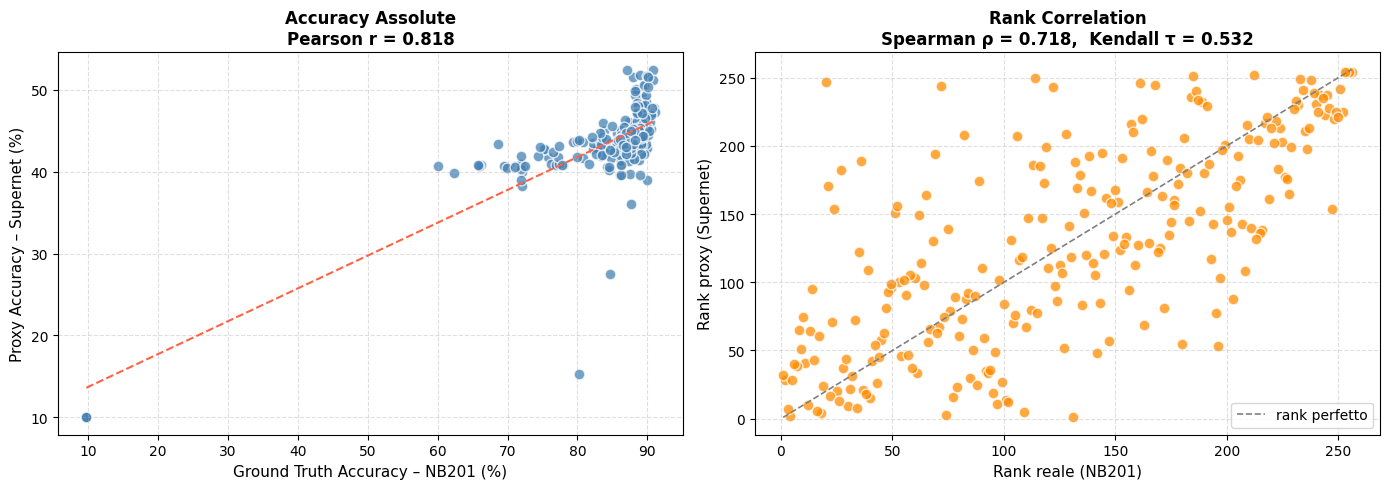

In [ ]:
# ── cella 2: confronto con ground truth ───────────────────────────────────────

df_results = fetch_gt_accuracies(
    networks   = population,    # list[NetworkDAG] dalla cella 1
    accuracies = accuracies,    # list[float] dalla supernet
    dataset    = 'cifar10-valid',
    hp         = '200',
)

print(df_results[['arch_str','Accuracy','GT_Accuracy']].to_string())

correlations = compute_and_plot_correlation(df_results)

In [ ]:
# df_results.to_csv('risultati_accuracies.csv', index=False)